# Global Superstore Sales Analysis

## Business Objective

Analyze sales, profit, customers, products, and regional performance to identify key business insights and provide data-driven recommendations.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Global_Superstore.csv")

## Dataset Understanding

Explore the structure, dimensions, and features of the dataset before performing analysis.

In [60]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [61]:
df.shape

(51290, 27)

In [62]:
df.columns


Index(['Category', 'City', 'Country', 'Customer ID', 'Customer Name',
       'Discount', 'Market', 'ji_lu-shu', 'Order Date', 'Order ID',
       'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity',
       'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode',
       'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  object 
 9   Order ID        51290 non-null  object 
 10  Order Priority  51290 non-null  object 
 11  Product ID      51290 non-null  object 
 12  Product Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [64]:
df.describe()

,Discount,ji_lu-shu,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [65]:
df[['Sales','Profit','Quantity','Discount','Shipping Cost']].describe()

,Sales,Profit,Quantity,Discount,Shipping Cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,28.610982,3.476545,0.142908,26.375818
std,487.567175,174.340972,2.278766,0.212280,57.296810
min,0.000000,-6599.978000,1.000000,0.000000,0.002000
25%,31.000000,0.000000,2.000000,0.000000,2.610000
50%,85.000000,9.240000,3.000000,0.000000,7.790000
75%,251.000000,36.810000,5.000000,0.200000,24.450000
max,22638.000000,8399.976000,14.000000,0.850000,933.570000


### Observation

The dataset contains sales, profit, customer, product, shipping, and regional information. Key business metrics such as Sales, Profit, Discount, and Quantity will be used throughout the analysis.

In [66]:
df.duplicated().sum()

0

In [67]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [68]:
df['Country'].nunique()

147

In [69]:
df.duplicated().sum()

0

In [70]:
df.shape

(51290, 27)

In [71]:
df.drop('ji_lu-shu', axis=1, inplace=True)

### Data Quality Review

- No duplicate records were found.
- The `ji_lu-shu` column contained no useful analytical information and was removed.
- The dataset covers 147 countries.

In [72]:
df['Sales'].sum()

12642905

In [73]:
df['Profit'].sum()

1467457.2912800002

In [74]:
df['Order ID'].nunique()



25035

In [75]:
print("Total Customers:", df['Customer ID'].nunique())
print("Countries Served:", df['Country'].nunique())

Total Customers: 4873
Countries Served: 147


### Key Findings

- Total Sales: 12.64 Million
- Total Profit: 1.47 Million
- Total Orders: 25,035
- Total Customers: 4,873
- Countries Served: 147

## Regional Sales Analysis

Analyze sales performance across regions to identify the largest revenue contributors.

In [76]:
sales_by_region = df.groupby('Region')['Sales'].sum()
print(sales_by_region)

Region
Africa             783776
Canada              66932
Caribbean          324281
Central           2822399
Central Asia       752839
EMEA               806184
East               678834
North             1248192
North Asia         848349
Oceania           1100207
South             1600960
Southeast Asia     884438
West               725514
Name: Sales, dtype: int64


In [77]:
sales_by_region.sort_values(ascending=False)

Region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: Sales, dtype: int64

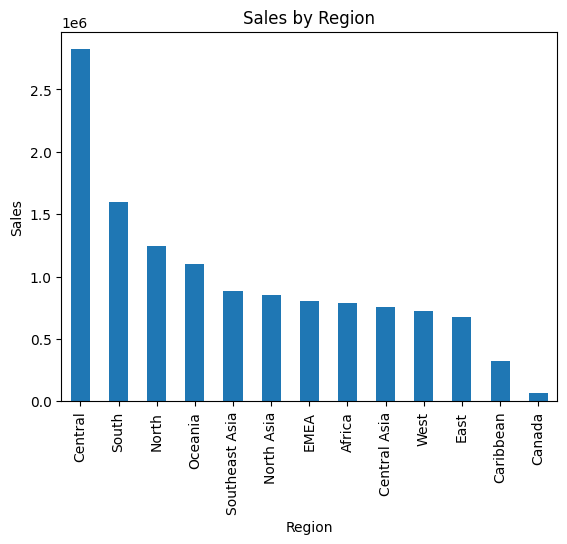

In [78]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

sales_by_region.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

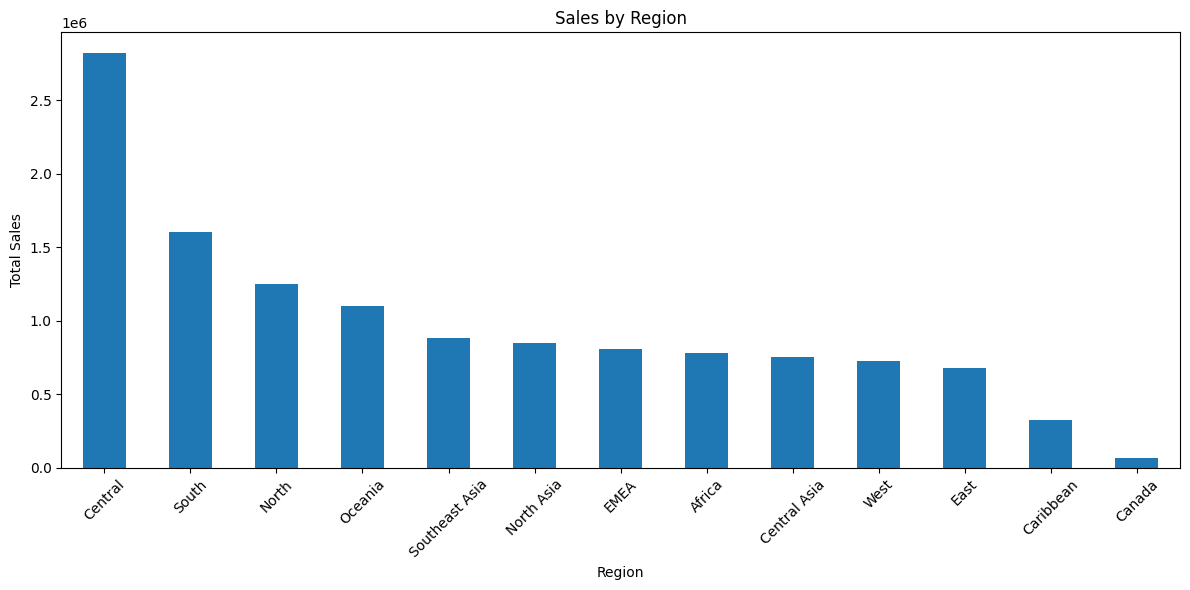

In [79]:
plt.figure(figsize=(12,6))

sales_by_region.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Insights

- Central region generated the highest sales.
- South region was the second-largest contributor.
- Canada generated the lowest sales among all regions.

## Category Analysis

Evaluate sales, profit, and profit margin across product categories.

In [80]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(sales_by_category)

Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64


In [81]:
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(profit_by_category)

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64


In [82]:
category_summary = df.groupby('Category')[['Sales','Profit']].sum()

category_summary['Profit Margin %'] = (
    category_summary['Profit'] /
    category_summary['Sales']
) * 100

print(category_summary)

                   Sales        Profit  Profit Margin %
Category                                               
Furniture        4110884  285204.72380         6.937795
Office Supplies  3787330  518473.83430        13.689693
Technology       4744691  663778.73318        13.989925


### Insights

- Technology generated the highest sales.
- Technology also generated the highest profit.
- Furniture produced lower profit margins compared to other categories.

## Customer Analysis

Identify the highest-value customers based on total sales.

In [83]:
top_customers = (
    df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10))

print(top_customers)

Customer Name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: Sales, dtype: int64


### Insights

A small group of customers contributes a significant portion of total revenue, highlighting the importance of customer retention and relationship management.

## Regional Profitability Analysis

Compare regional profit performance and profit margins.

In [84]:
profit_by_region = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print(profit_by_region)

Region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: Profit, dtype: float64


In [85]:
region_summary = df.groupby('Region')[['Sales','Profit']].sum()

region_summary['Profit Margin %'] = (
    region_summary['Profit'] /
    region_summary['Sales']
) * 100

print(region_summary.sort_values('Profit Margin %', ascending=False))

                  Sales        Profit  Profit Margin %
Region                                                
Canada            66932   17817.39000        26.620137
North Asia       848349  165578.42100        19.517725
Central Asia     752839  132480.18700        17.597413
North           1248192  194597.95252        15.590386
West             725514  108418.44890        14.943674
East             678834   91522.78000        13.482351
Africa           783776   88871.63100        11.338907
Central         2822399  311403.98164        11.033308
Oceania         1100207  120089.11200        10.915138
Caribbean        324281   34571.32104        10.660915
South           1600960  140355.76618         8.766975
EMEA             806184   43897.97100         5.445155
Southeast Asia   884438   17852.32900         2.018494


### Insights

- Central region generated the highest total profit.
- Canada achieved the highest profit margin.
- Southeast Asia recorded the lowest profit margin despite strong sales.

## Sales Trend Analysis

Analyze sales growth over time.

In [86]:
sales_by_year = df.groupby('Year')['Sales'].sum()

print(sales_by_year)

Year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: Sales, dtype: int64


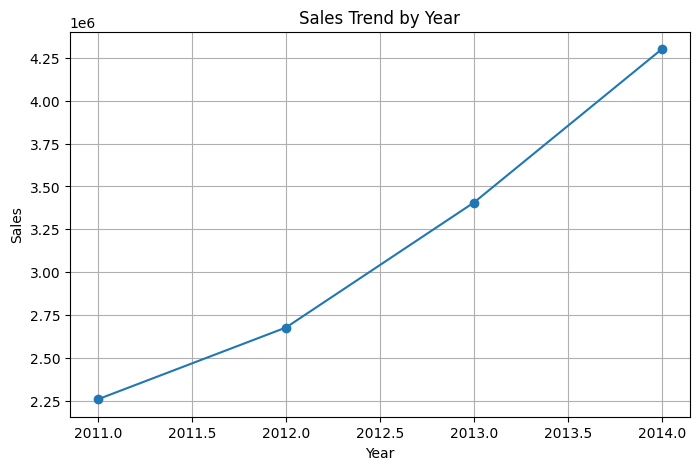

In [87]:
import matplotlib.pyplot as plt

sales_by_year = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8,5))
sales_by_year.plot(kind='line', marker='o')

plt.title('Sales Trend by Year')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.grid(True)

plt.show()

In [88]:
sales_by_year = df.groupby('Year')['Sales'].sum()

growth = sales_by_year.pct_change() * 100

print(growth)

Year
2011          NaN
2012    18.498781
2013    27.203320
2014    26.254191
Name: Sales, dtype: float64


### Insights

Sales increased consistently from 2011 to 2014, indicating strong business growth and expanding market performance.

## Product Analysis

Identify the highest-performing and lowest-performing products.

In [89]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: Sales, dtype: int64


In [90]:
top_profit_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_profit_products)


Product Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64


In [91]:
loss_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values()
      .head(10)
)

print(loss_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Motorola Smart Phone, Cordless                             -4447.0380
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Rogers Lockers, Blue                                       -2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, with Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
Name: Profit, dtype: float64


### Insights

- Smartphones and office equipment generated substantial sales.
- Some products generated significant losses despite strong sales performance.
- Loss-making products should be reviewed for pricing, discounts, or operational costs.

## Correlation Analysis

Evaluate relationships between Sales, Profit, and Discount.

In [92]:
print(df[['Sales','Profit','Discount']].corr())

             Sales    Profit  Discount
Sales     1.000000  0.484923 -0.086728
Profit    0.484923  1.000000 -0.316490
Discount -0.086728 -0.316490  1.000000


### Insights

- Sales and Profit show a positive relationship.
- Discounts have a negative relationship with Profit.
- Excessive discounting may reduce overall profitability.

## Shipping Analysis

Analyze profit contribution by shipping mode.

In [93]:
ship_profit = (
    df.groupby('Ship Mode')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print(ship_profit)

Ship Mode
Standard Class    890596.02120
Second Class      292583.52708
First Class       208104.67520
Same Day           76173.06780
Name: Profit, dtype: float64


### Insights

Standard Class generated the highest total profit among all shipping methods.

## Export Cleaned Dataset

Save the cleaned dataset for use in SQL, Power BI, and future analysis.

In [94]:
df = df.drop(['Order Date', 'Ship Date'], axis=1)

In [95]:
df.to_csv('superstore_cleaned.csv', index=False)

# Business Recommendations

1. Focus on Technology products due to strong profitability.

2. Review discount strategies to reduce profit erosion.

3. Investigate loss-making products and optimize pricing.

4. Learn from high-margin regions such as Canada.

5. Continue investing in high-performing regions and customer segments.

## MySQL Database Integration

The cleaned dataset was imported into a MySQL database using SQLAlchemy and PyMySQL. SQL queries were then used to validate and reproduce key business insights obtained during the Pandas analysis.

# SQL Analysis Using MySQL

In [96]:
import sqlalchemy
import pymysql

print("Packages installed successfully!")

Packages installed successfully!


In [97]:
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+pymysql://root:@localhost/superstore_db"
)

print("Connected Successfully!")

Connected Successfully!


In [98]:
import pandas as pd

df_sql = pd.read_csv("superstore_cleaned.csv")

print(df_sql.shape)

(51290, 24)


In [99]:
df_sql.to_sql(
    name='superstore',
    con=engine,
    if_exists='replace',
    index=False
)

print("Data Uploaded Successfully!")

Data Uploaded Successfully!


## Total Sales and Profit

This query calculates the overall sales and profit generated by the business across all transactions.

In [100]:
query = """
SELECT
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM superstore;
"""

result = pd.read_sql(query, engine)

result

,Total_Sales,Total_Profit
0,12642905.0,1.467457e+06


## Sales by Region

This query identifies the regions generating the highest sales revenue.

In [101]:
query = """
SELECT
    Region,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

sales_region_sql = pd.read_sql(query, engine)

sales_region_sql

,Region,Total_Sales
0,Central,2822399.0
1,South,1600960.0
2,North,1248192.0
3,Oceania,1100207.0
4,Southeast Asia,884438.0
5,North Asia,848349.0
6,EMEA,806184.0
7,Africa,783776.0
8,Central Asia,752839.0
9,West,725514.0


## Profit by Region

This query evaluates the profitability of each region.

In [102]:
query = """
SELECT
    Region,
    SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

pd.read_sql(query, engine)

,Region,Total_Profit
0,Central,311403.98164
1,North,194597.95252
2,North Asia,165578.42100
3,South,140355.76618
4,Central Asia,132480.18700
5,Oceania,120089.11200
6,West,108418.44890
7,East,91522.78000
8,Africa,88871.63100
9,EMEA,43897.97100


## Sales by Category

This query compares sales performance across product categories.

In [103]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

pd.read_sql(query, engine)

,Category,Total_Sales
0,Technology,4744691.0
1,Furniture,4110884.0
2,Office Supplies,3787330.0


## Top 10 Customers

This query identifies customers contributing the highest sales.

In [104]:
query = """
SELECT
    `Customer Name`,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY `Customer Name`
ORDER BY Total_Sales DESC
LIMIT 10;
"""

pd.read_sql(query, engine)

,Customer Name,Total_Sales
0,Tom Ashbrook,40489.0
1,Tamara Chand,37453.0
2,Greg Tran,35552.0
3,Christopher Conant,35187.0
4,Sean Miller,35170.0
5,Bart Watters,32315.0
6,Natalie Fritzler,31778.0
7,Fred Hopkins,30404.0
8,Jane Waco,30288.0
9,Hunter Lopez,30246.0


## Top Products by Sales

This query identifies the best-selling products.

In [105]:
query = """
SELECT
    `Product Name`,
    SUM(Sales) AS Total_Sales
FROM superstore
GROUP BY `Product Name`
ORDER BY Total_Sales DESC
LIMIT 10;
"""

pd.read_sql(query, engine)

,Product Name,Total_Sales
0,"Apple Smart Phone, Full Size",86936.0
1,"Cisco Smart Phone, Full Size",76441.0
2,"Motorola Smart Phone, Full Size",73159.0
3,"Nokia Smart Phone, Full Size",71904.0
4,Canon imageCLASS 2200 Advanced Copier,61600.0
5,"Hon Executive Leather Armchair, Adjustable",58200.0
6,"Office Star Executive Leather Armchair, Adjust...",50667.0
7,"Harbour Creations Executive Leather Armchair, ...",50120.0
8,"Samsung Smart Phone, Cordless",48654.0
9,"Nokia Smart Phone, with Caller ID",47880.0


## Most Profitable Products

This query identifies products generating the highest profit.

In [106]:
query = """
SELECT
    `Product Name`,
    SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY `Product Name`
ORDER BY Total_Profit DESC
LIMIT 10;
"""

pd.read_sql(query, engine)

,Product Name,Total_Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,"Cisco Smart Phone, Full Size",17238.5206
2,"Motorola Smart Phone, Full Size",17027.1130
3,"Hoover Stove, Red",11807.9690
4,"Sauder Classic Bookcase, Traditional",10672.0730
5,"Harbour Creations Executive Leather Armchair, ...",10427.3260
6,"Nokia Smart Phone, Full Size",9938.1955
7,"Cisco Smart Phone, with Caller ID",9786.6408
8,"Nokia Smart Phone, with Caller ID",9465.3257
9,"Belkin Router, USB",8955.0180


## Loss-Making Products

This query identifies products that generated the largest losses.

In [107]:
query = """
SELECT
    `Product Name`,
    SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY `Product Name`
ORDER BY Total_Profit ASC
LIMIT 10;
"""

pd.read_sql(query, engine)

,Product Name,Total_Profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,"Motorola Smart Phone, Cordless",-4447.0380
3,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
4,"Bevis Round Table, Adjustable Height",-3649.8940
5,"Bevis Computer Table, Fully Assembled",-3509.5638
6,"Rogers Lockers, Blue",-2893.4908
7,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
8,"Bevis Wood Table, with Bottom Storage",-2782.5880
9,"Lesro Training Table, Rectangular",-2581.2834


## Profit by Shipping Mode

This query evaluates which shipping methods contribute the most profit.

In [108]:
query = """
SELECT
    `Ship Mode`,
    SUM(Profit) AS Total_Profit
FROM superstore
GROUP BY `Ship Mode`
ORDER BY Total_Profit DESC;
"""

pd.read_sql(query, engine)

,Ship Mode,Total_Profit
0,Standard Class,890596.02120
1,Second Class,292583.52708
2,First Class,208104.67520
3,Same Day,76173.06780


## Customer Count

This query calculates the number of unique customers served.

In [109]:
query = """
SELECT
    COUNT(DISTINCT `Customer ID`) AS Total_Customers
FROM superstore;
"""

pd.read_sql(query, engine)

,Total_Customers
0,4873
